# 1-1 Titanic 데이터로 배우는 EDA

## 수업 내용

- EDA(탐색적 데이터 분석)의 의미
- Titanic 데이터셋 구조 확인
- 결측치와 기술통계 확인
- 범주형 데이터의 빈도와 생존율 분석
- 상관관계와 히트맵
- 분포, 분산, 이상치 이해
- 여러 변수를 한 번에 살펴보는 `pairplot`

# 0. EDA를 하기전에...

## Pandas와 NumPy를 이용한 머신러닝 데이터 처리 과정

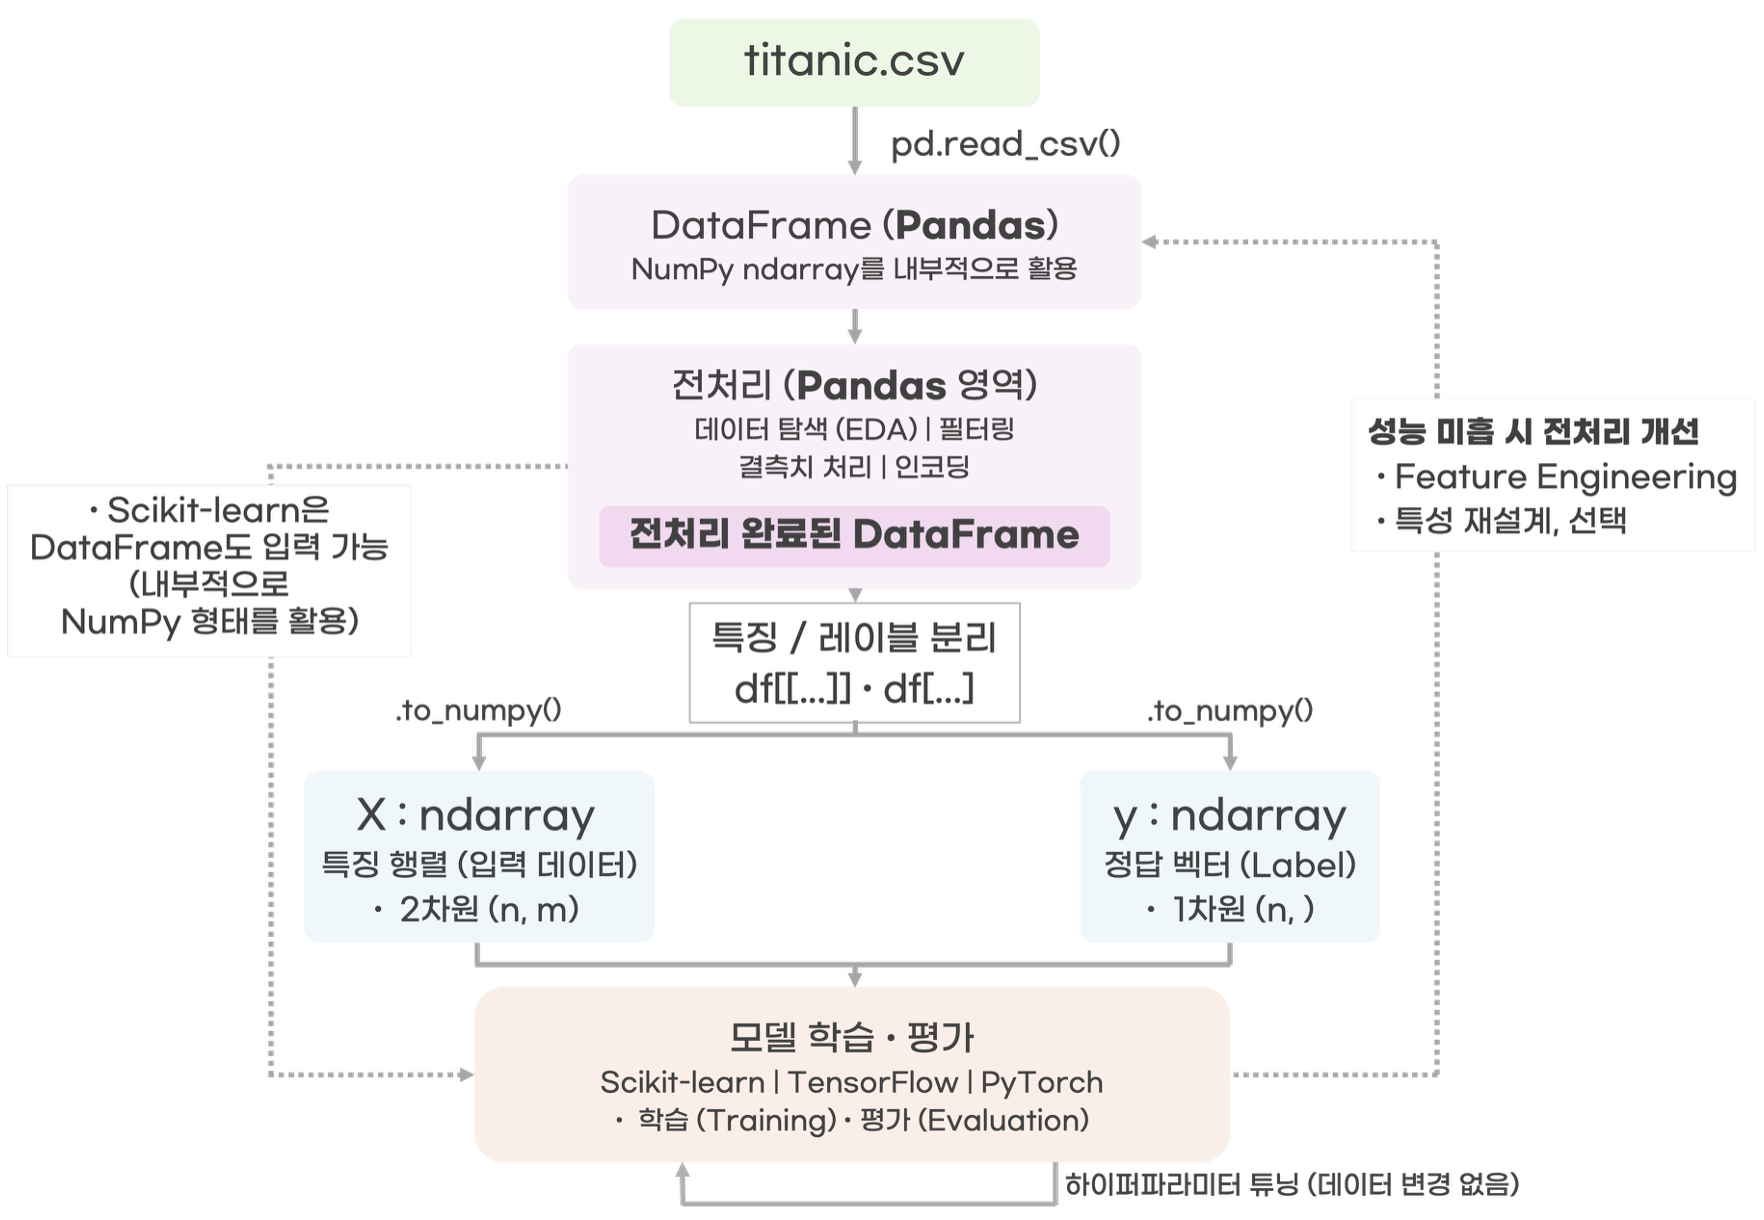

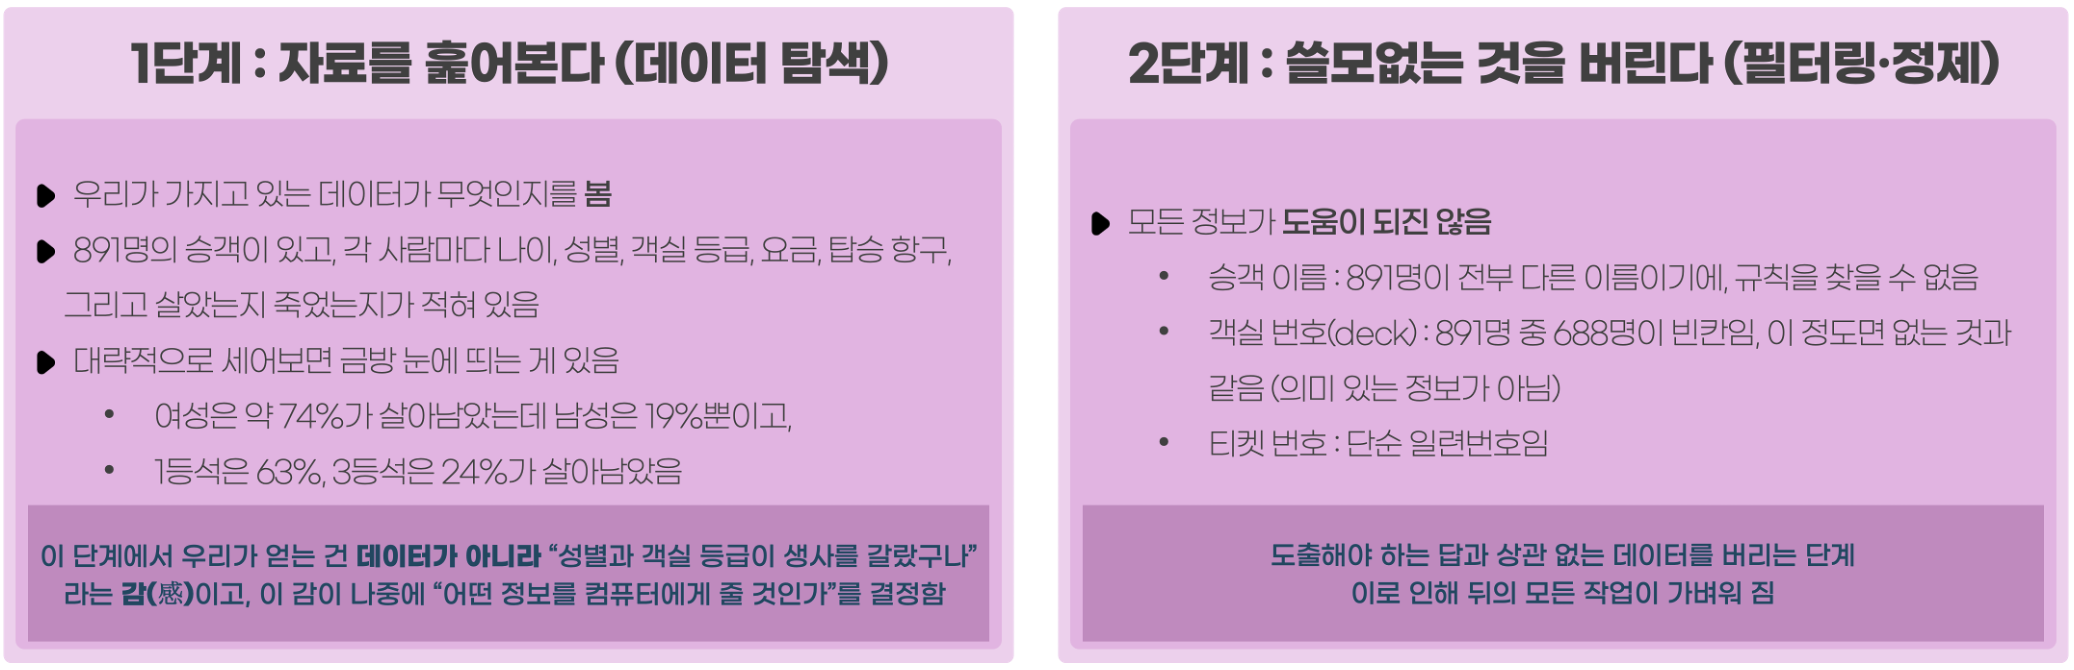

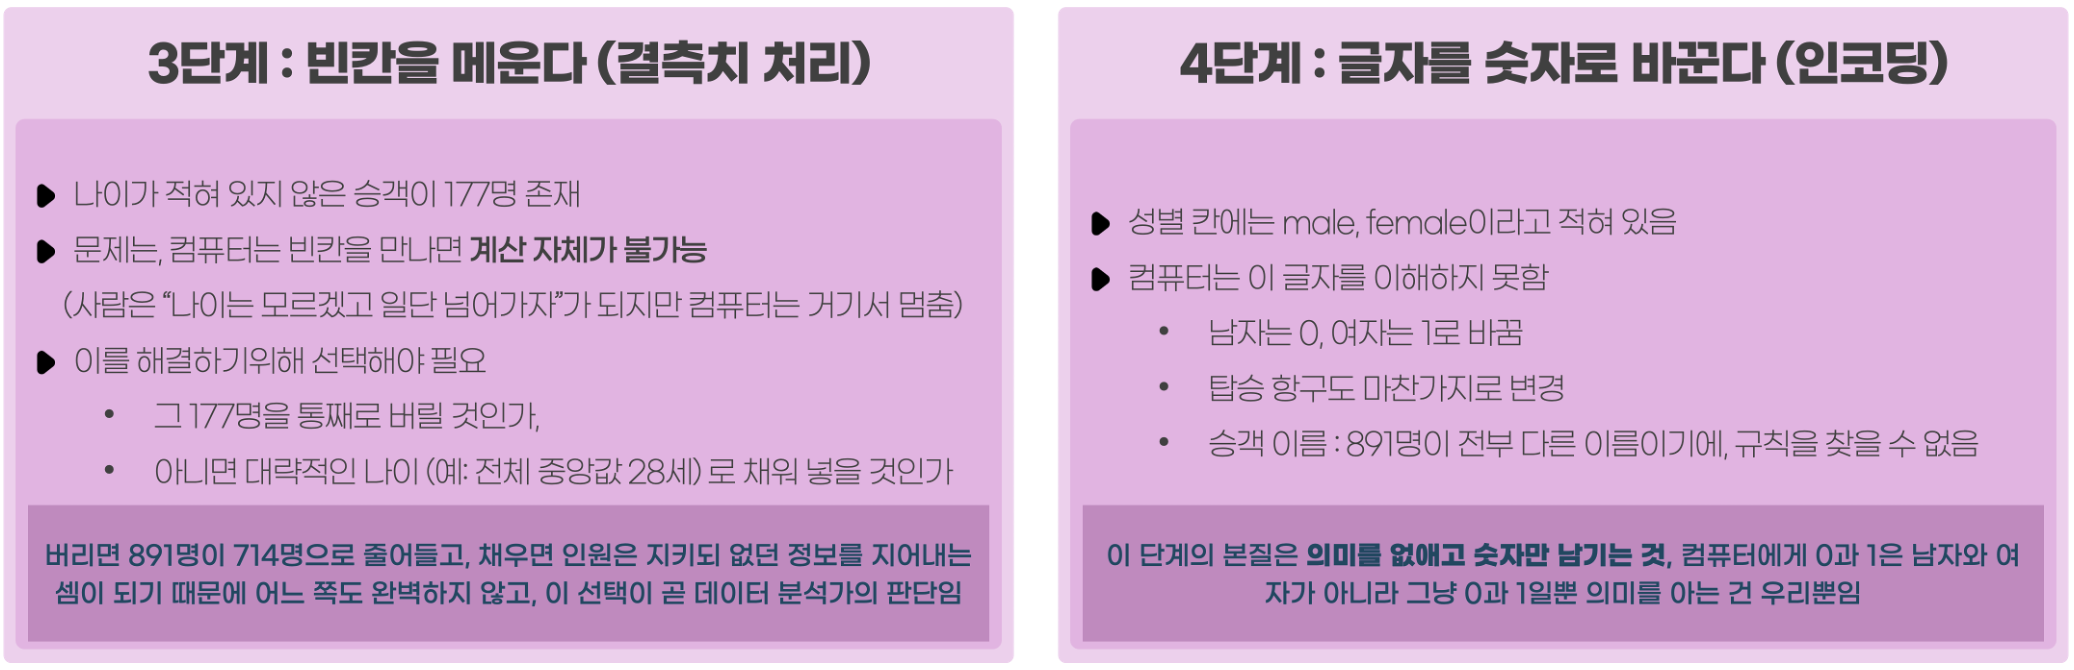

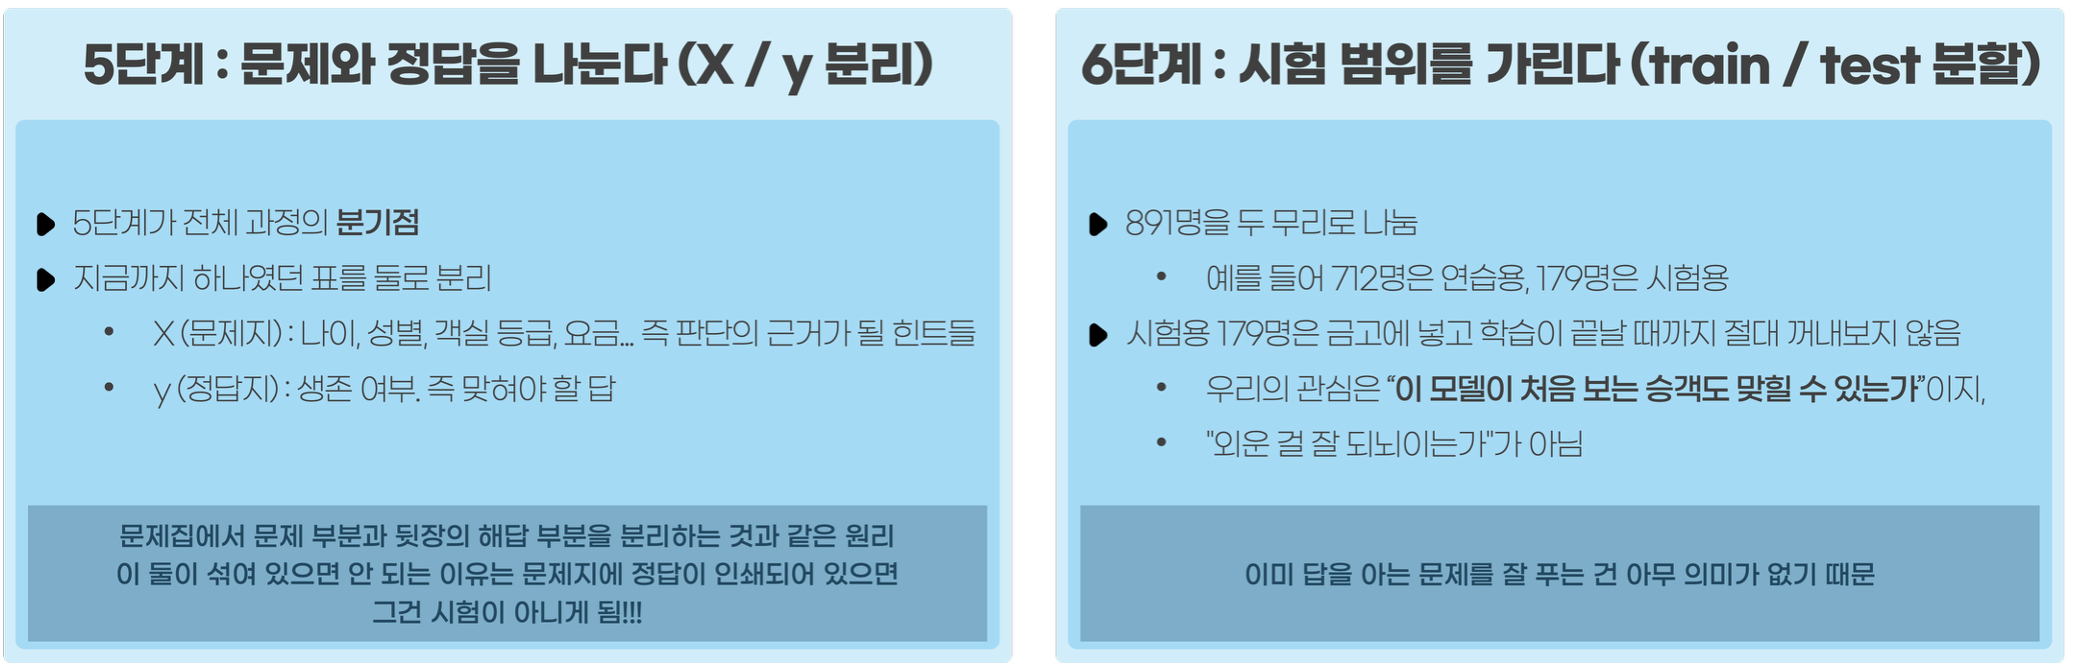

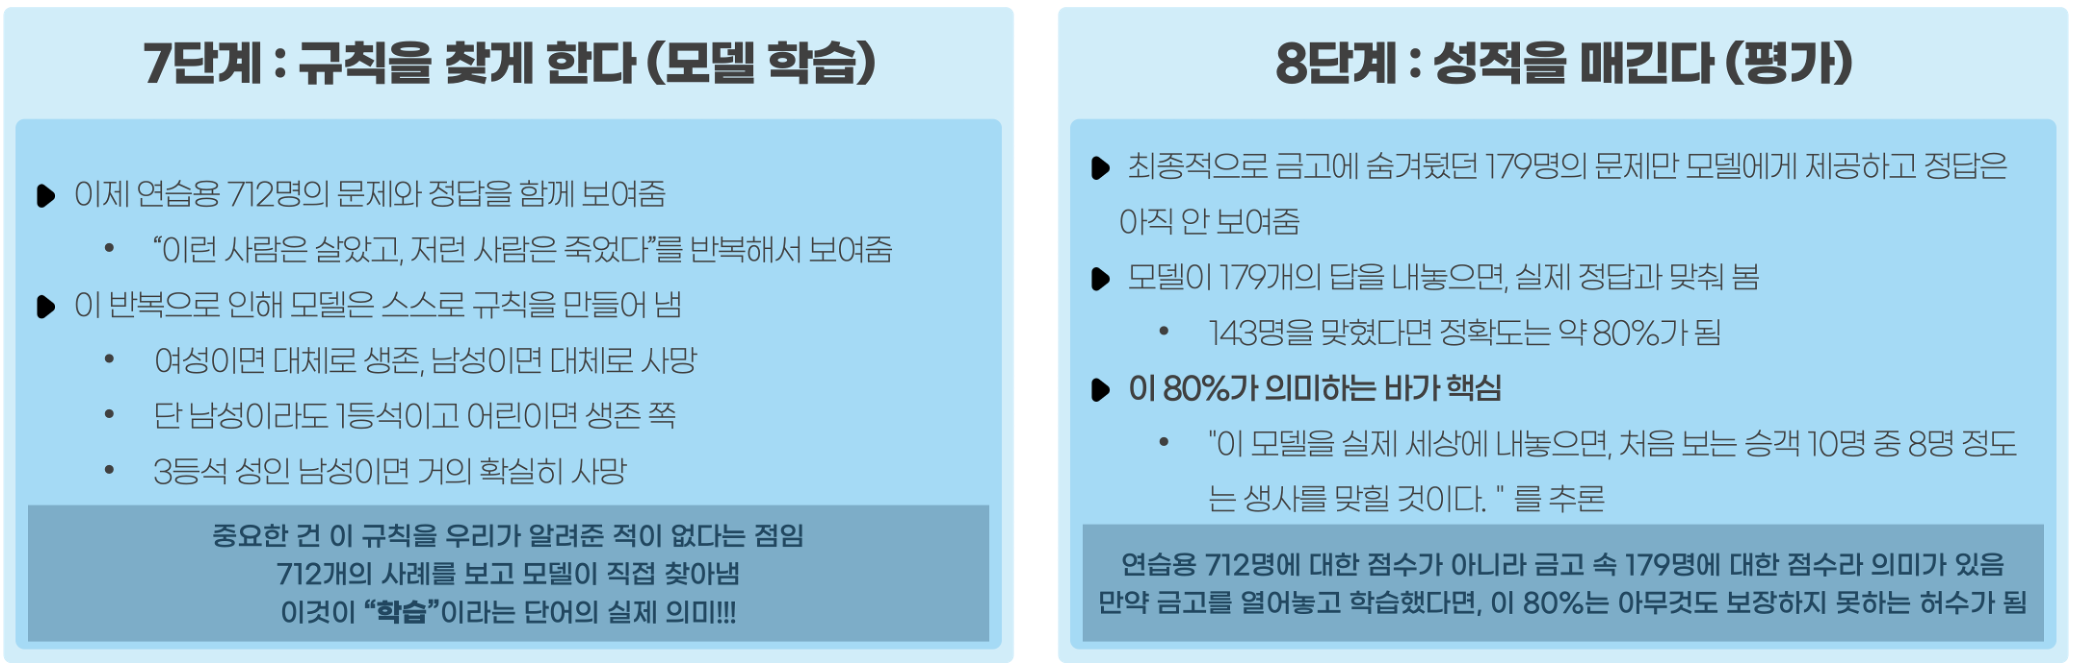

# 1. EDA란 무엇인가요?

EDA는 **Exploratory Data Analysis**, 즉 **탐색적 데이터 분석**입니다.

데이터를 본격적으로 분석하거나 모델을 만들기 전에 다음과 같은 질문을 확인하는 과정입니다.

- 데이터는 몇 행, 몇 열인가?
- 어떤 컬럼이 있는가?
- 각 컬럼은 어떤 자료형인가?
- 결측치는 어디에 얼마나 있는가?
- 값은 어느 구간에 많이 모여 있는가?
- 범주별 개수와 비율은 어떠한가?
- 변수 사이에 관계가 있는가?
- 이상하게 크거나 작은 값이 있는가?

데이터를 출력하거나 표와 그래프로 살펴보는 행동은 모두 EDA에 포함됩니다.

## EDA와 전처리의 차이

- **EDA**: 결측치, 이상치, 분포, 관계 등을 **찾고 이해하는 과정**
- **전처리**: 결측치를 채우거나 삭제하고, 값을 변환하는 등 데이터를 **수정하는 과정**

이 노트북에서는 데이터를 함부로 변경하지 않고, 먼저 관찰하고 해석하는 데 집중합니다.

# 2. Titanic 데이터셋 이해하기

Titanic 데이터셋은 타이타닉호 승객의 정보와 생존 여부를 담고 있습니다.

주요 컬럼은 다음과 같습니다.

| 컬럼 | 의미 |
|---|---|
| `survived` | 생존 여부: 0=사망, 1=생존 |
| `pclass` | 객실 등급: 1, 2, 3등급 |
| `sex` | 성별 |
| `age` | 나이 |
| `sibsp` | 함께 탑승한 형제·자매·배우자 수 |
| `parch` | 함께 탑승한 부모·자녀 수 |
| `fare` | 운임 |
| `embarked` | 승선 항구 코드 |
| `class` | 객실 등급 이름 |
| `who` | 남성, 여성, 어린이 구분 |
| `adult_male` | 성인 남성 여부 |
| `deck` | 갑판 |
| `embark_town` | 승선 도시 |
| `alive` | 생존 여부 문자열 |
| `alone` | 혼자 탑승했는지 여부 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프의 기본 크기와 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 현재 노트북과 같은 폴더에 있는 CSV 파일 읽기
df = pd.read_csv("titanic.csv")

# 앞부분 5개 행 확인
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 데이터의 앞부분과 뒷부분 확인

- `head()`는 앞에서부터 기본 5개 행을 보여줍니다.
- `tail()`은 뒤에서부터 기본 5개 행을 보여줍니다.
- 괄호 안에 숫자를 넣으면 출력할 행의 개수를 지정할 수 있습니다.

In [2]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


# 3. 데이터 크기, 컬럼, 자료형 확인

먼저 데이터의 전체적인 구조를 확인합니다.

In [3]:
print("데이터 크기:", df.shape)
print("행 개수:", df.shape[0])
print("열 개수:", df.shape[1])
print("\n컬럼 목록:")
print(df.columns.tolist())

데이터 크기: (891, 15)
행 개수: 891
열 개수: 15

컬럼 목록:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


`info()`에서 확인할 수 있는 내용은 다음과 같습니다.

- 전체 행 개수
- 컬럼 이름
- 결측치가 아닌 값의 개수
- 자료형
- 메모리 사용량

Titanic 데이터에서는 특히 `age`, `embarked`, `deck`, `embark_town` 컬럼에 결측치가 있는지 살펴봅니다.

## 컬럼별 결측치 개수 확인

`isna()`는 각 값이 결측치인지 확인하고, `sum()`을 연결하면 컬럼별 결측치 개수를 계산할 수 있습니다.

In [5]:
missing_count = df.isna().sum()
missing_count[missing_count > 0].sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
dtype: int64

## 결측치 비율 확인

개수만 보는 것보다 전체 데이터 중 몇 퍼센트가 비어 있는지 함께 보면 결측치의 심각성을 판단하기 쉽습니다.

In [6]:
missing_rate = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "결측치 개수": missing_count,
    "결측치 비율(%)": missing_rate
})

missing_summary[missing_summary["결측치 개수"] > 0].sort_values(
    "결측치 비율(%)", ascending=False
)

,결측치 개수,결측치 비율(%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


# 4. 기술통계 확인

`describe()`는 수치형 컬럼의 다음 통계량을 요약합니다.

- `count`: 결측치를 제외한 값의 개수
- `mean`: 평균
- `std`: 표준편차
- `min`: 최솟값
- `25%`, `50%`, `75%`: 사분위수
- `max`: 최댓값

In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


범주형 데이터도 `include="object"`를 사용하면 빈도 정보를 확인할 수 있습니다.

- `unique`: 서로 다른 값의 개수
- `top`: 가장 자주 등장한 값
- `freq`: 가장 자주 등장한 값의 빈도

In [8]:
df.describe(include="object")

/var/folders/y8/nkl5y8tx52xcdmqbfbssc4pr0000gn/T/ipykernel_48357/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,embarked,class,who,deck,embark_town,alive
count,891,889,891,891,203,889,891
unique,2,3,3,3,7,3,2
top,male,S,Third,man,C,Southampton,no
freq,577,644,491,537,59,644,549


# 5. 범주형 데이터 살펴보기

범주형 데이터는 평균보다 **각 값의 개수와 비율**을 확인하는 것이 중요합니다.

먼저 성별 탑승객 수를 확인합니다.

In [9]:
df["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [10]:
# .value_counts(): 각 값의 개수 계산, male 577, female 314
# .value_counts(normalize=True) 개수가 아닌 비율 계산, male 0.647, female 0.353
# .mul(100) 100을 곱해 백분율(%)로 변환, male 64.7, female 35.3
# .round(1) 소수점 첫째 자리까지 반올림, male 64.8, female 35.2
df["sex"].value_counts(normalize=True).mul(100).round(1)

sex
male      64.8
female    35.2
Name: proportion, dtype: float64

## 객실 등급별 탑승객 수

In [11]:
df["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

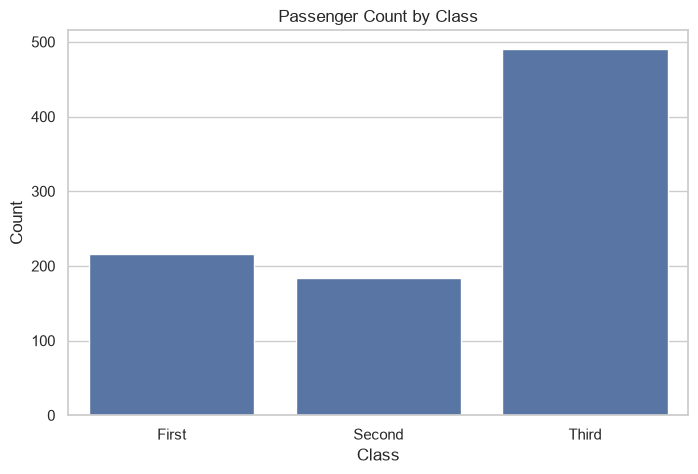

In [12]:
sns.countplot(data=df, x="class", order=["First", "Second", "Third"], color="C0")
plt.title("Passenger Count by Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## 전체 생존자와 사망자 수

In [13]:
survival_counts = df["survived"].value_counts().sort_index()
survival_counts.index = ["사망", "생존"]
survival_counts

사망    549
생존    342
Name: count, dtype: int64

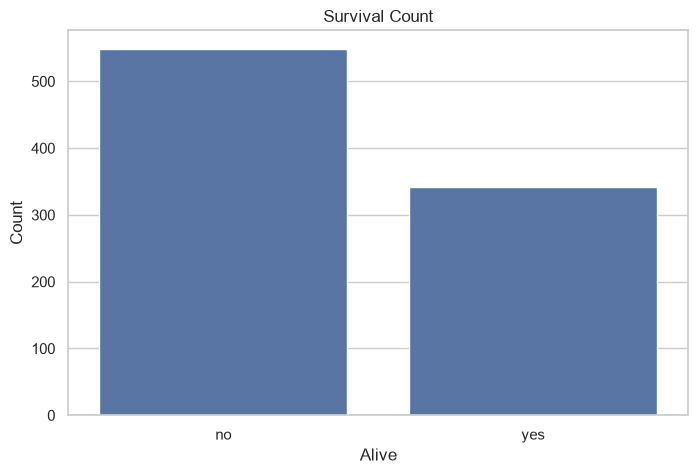

In [14]:
sns.countplot(data=df, x="alive", order=["no", "yes"], color="C0")
plt.title("Survival Count")
plt.xlabel("Alive")
plt.ylabel("Count")
plt.show()

# 6. 그룹별 생존율 분석

`survived`는 사망이 0, 생존이 1입니다.  
따라서 그룹별 `survived`의 평균을 구하면 해당 그룹의 **생존율**이 됩니다.

## 성별 생존율

In [15]:
survival_by_sex = (
    df.groupby("sex")["survived"]
      .mean()
      .mul(100)
      .round(1)
)

survival_by_sex

sex
female    74.2
male      18.9
Name: survived, dtype: float64

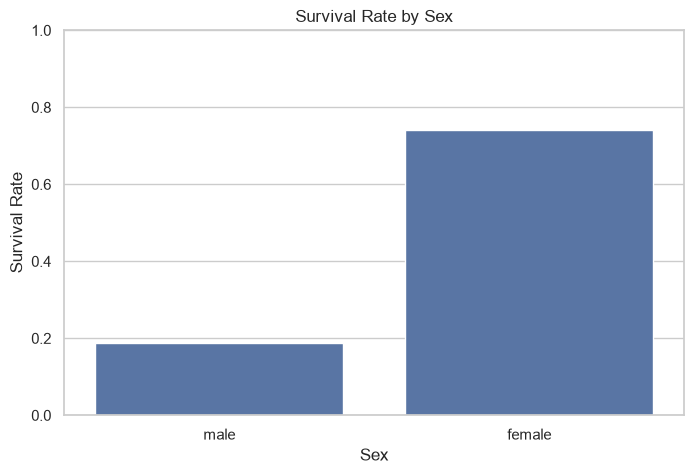

In [16]:
sns.barplot(data=df, x="sex", y="survived", errorbar=None, color="C0")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

그래프의 세로축은 0부터 1 사이의 비율입니다.

- 0.0 = 0%
- 0.5 = 50%
- 1.0 = 100%

객실 등급별에 따라 생존율 차이가 있는지 관찰

## 객실 등급별 생존율

In [17]:
survival_by_class = (
    df.groupby("class", observed=False)["survived"]
      .mean()
      .reindex(["First", "Second", "Third"])
      .mul(100)
      .round(1)
)

survival_by_class

class
First     63.0
Second    47.3
Third     24.2
Name: survived, dtype: float64

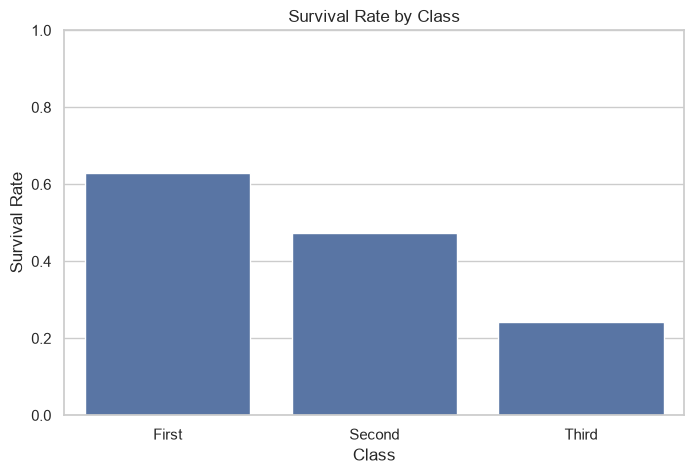

In [18]:
sns.barplot(
    data=df,
    x="class",
    y="survived",
    order=["First", "Second", "Third"],
    errorbar=None,
    color="C0"
)
plt.title("Survival Rate by Class")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

## 성별과 객실 등급을 함께 비교

In [19]:
survival_table = pd.crosstab(
    df["class"],
    df["sex"],
    values=df["survived"],
    aggfunc="mean"
).reindex(["First", "Second", "Third"])

(survival_table * 100).round(1)

sex,female,male
class,,
First,96.8,36.9
Second,92.1,15.7
Third,50.0,13.5


/var/folders/y8/nkl5y8tx52xcdmqbfbssc4pr0000gn/T/ipykernel_48357/119235797.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:C0'` for the same effect.

  sns.barplot(


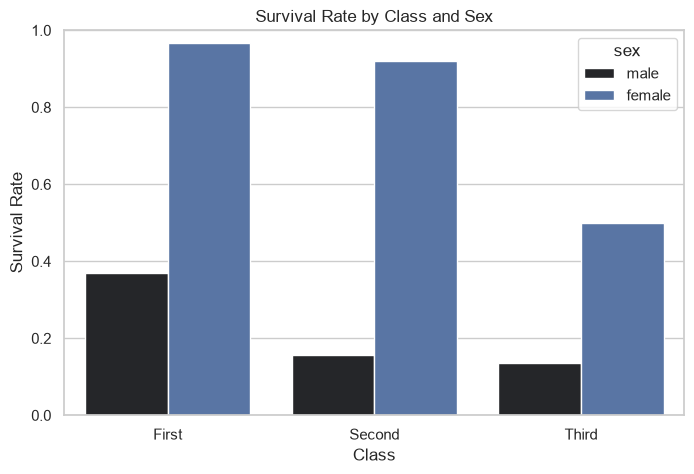

In [20]:
sns.barplot(
    data=df,
    x="class",
    y="survived",
    hue="sex",
    order=["First", "Second", "Third"],
    errorbar=None,
    color="C0"
)
plt.title("Survival Rate by Class and Sex")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

# 7. 수치형 데이터의 분포

분포는 값이 어느 구간에 많이 모여 있고 얼마나 퍼져 있는지를 나타내는 **모양**입니다.

히스토그램을 사용하면 연속형 값의 분포를 쉽게 확인할 수 있습니다.

## 나이 분포

`age`에는 결측치가 있지만, Seaborn은 그래프를 그릴 때 결측치를 자동으로 제외합니다.

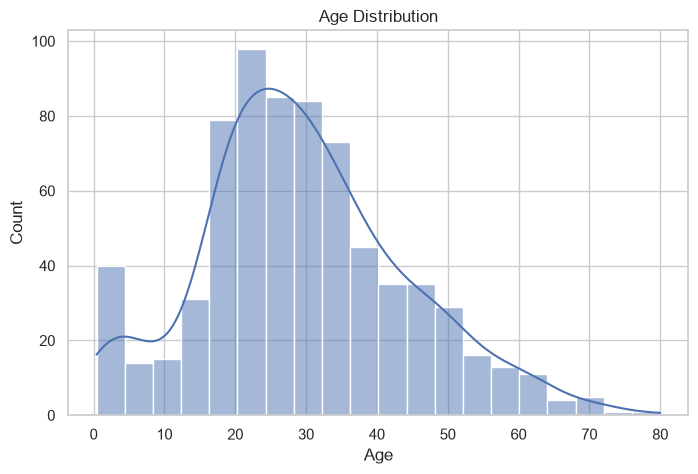

In [21]:
sns.histplot(data=df, x="age", bins=20, kde=True, color="C0")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

확인할 내용:

- 승객이 가장 많이 몰린 나이 구간은 어디인가?
- 어린이와 고령 승객은 얼마나 있는가?
- 분포가 한쪽으로 치우쳐 있는가?

## 운임 분포

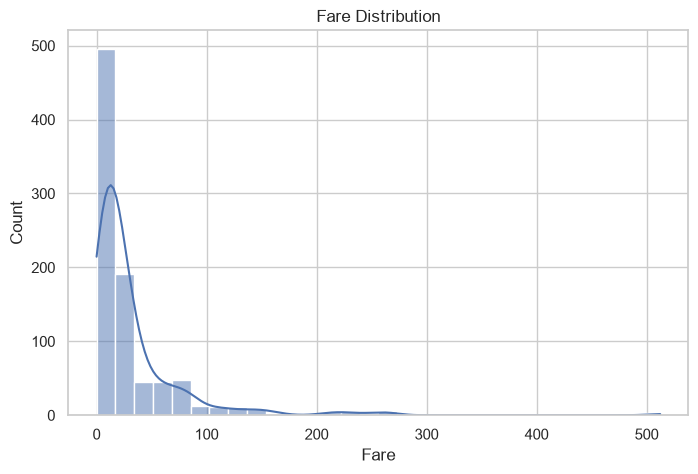

In [22]:
sns.histplot(data=df, x="fare", bins=30, kde=True, color="C0")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

운임은 낮은 값에 많은 승객이 모여 있고, 일부 매우 큰 값이 존재합니다.  
이처럼 한쪽 꼬리가 길게 늘어진 분포를 **오른쪽으로 치우친 분포**라고 합니다.

## 객실 등급별 나이 분포 비교

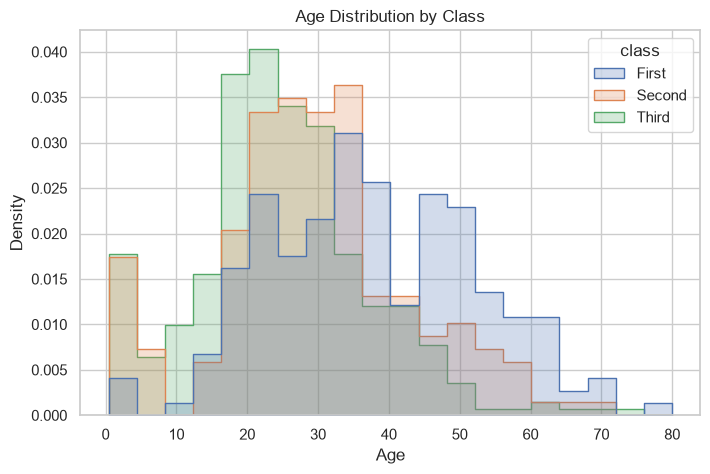

In [23]:
sns.histplot(
    data=df,
    x="age",
    hue="class",
    hue_order=["First", "Second", "Third"],
    bins=20,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Age Distribution by Class")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

# 8. 이상치 살펴보기

EDA에서는 이상치를 바로 삭제하지 않습니다.  
먼저 상자 그림(Box Plot)을 이용해 값의 범위와 특이하게 크거나 작은 값을 확인합니다.

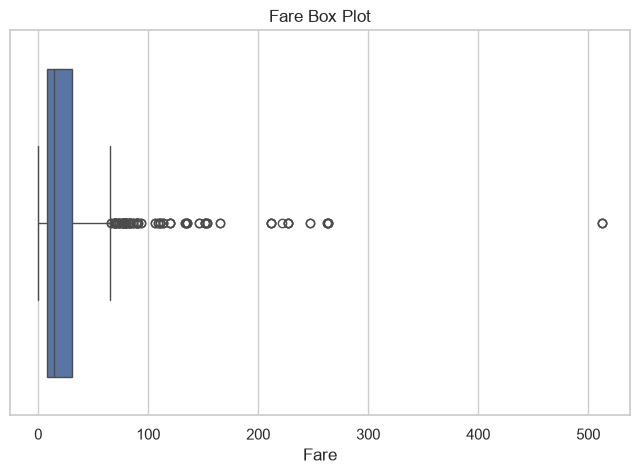

In [24]:
sns.boxplot(data=df, x="fare", color="C0")
plt.title("Fare Box Plot")
plt.xlabel("Fare")
plt.show()

상자 그림의 기본 구성:

- 상자 가운데 선: 중앙값
- 상자의 양쪽 끝: 1사분위수와 3사분위수
- 수염 바깥의 점: 일반적인 범위를 크게 벗어난 값

수염 바깥의 값이 반드시 오류라는 뜻은 아닙니다.  
실제 1등급 고가 객실의 정상적인 운임일 수도 있으므로 데이터의 의미를 함께 확인해야 합니다.

## 객실 등급별 운임 비교

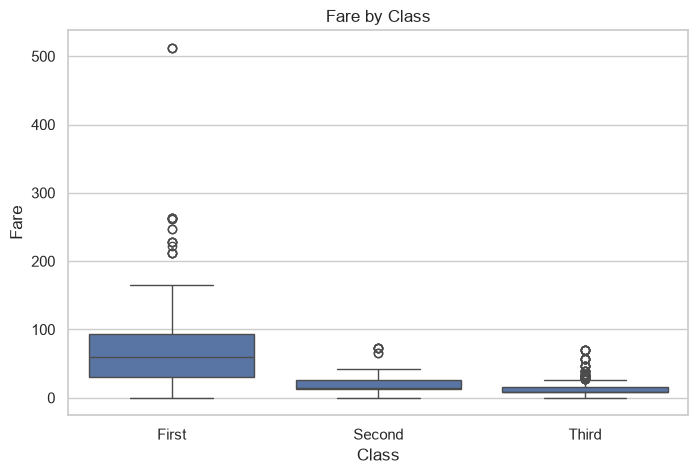

In [25]:
sns.boxplot(
    data=df,
    x="class",
    y="fare",
    order=["First", "Second", "Third"],
    color="C0"
)
plt.title("Fare by Class")
plt.xlabel("Class")
plt.ylabel("Fare")
plt.show()

# 9. 두 변수의 관계 살펴보기

산점도는 두 수치형 변수의 관계를 점으로 표현합니다.

Titanic 데이터에서 나이와 운임 사이에 뚜렷한 관계가 있는지 살펴봅니다.

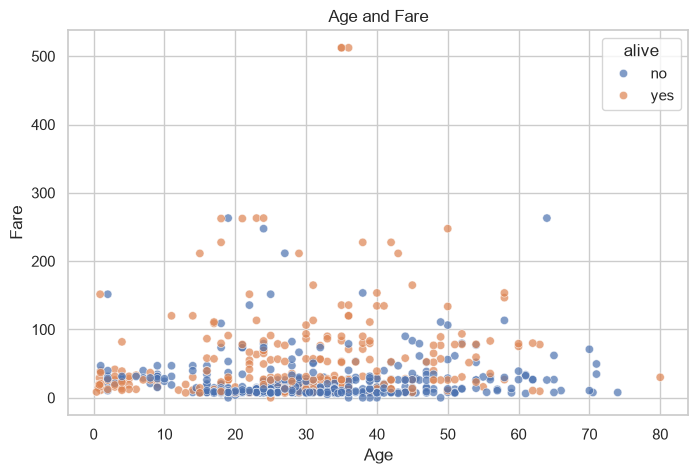

In [26]:
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="alive",
    alpha=0.7
)
plt.title("Age and Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

산점도를 해석할 때 확인할 내용:

- 한 변수가 커질 때 다른 변수도 함께 커지는가?
- 반대로 움직이는가?
- 뚜렷한 관계가 없는가?
- 특정 구간에 점이 몰려 있는가?
- 다른 점들과 멀리 떨어진 이상치가 있는가?

# 10. 상관관계

상관계수는 두 수치형 변수가 함께 움직이는 정도를 -1에서 1 사이의 값으로 나타냅니다.

- 1에 가까움: 강한 양의 상관관계
- -1에 가까움: 강한 음의 상관관계
- 0에 가까움: 선형적인 관계가 약함

> 상관관계가 있다고 해서 반드시 원인과 결과 관계라는 뜻은 아닙니다.

In [27]:
numeric_df = df.select_dtypes(include="number")
corr = numeric_df.corr()

corr.round(2)

,survived,pclass,age,sibsp,parch,fare
survived,1.00,-0.34,-0.08,-0.04,0.08,0.26
pclass,-0.34,1.00,-0.37,0.08,0.02,-0.55
age,-0.08,-0.37,1.00,-0.31,-0.19,0.10
sibsp,-0.04,0.08,-0.31,1.00,0.41,0.16
parch,0.08,0.02,-0.19,0.41,1.00,0.22
fare,0.26,-0.55,0.10,0.16,0.22,1.00


## 상관관계 히트맵

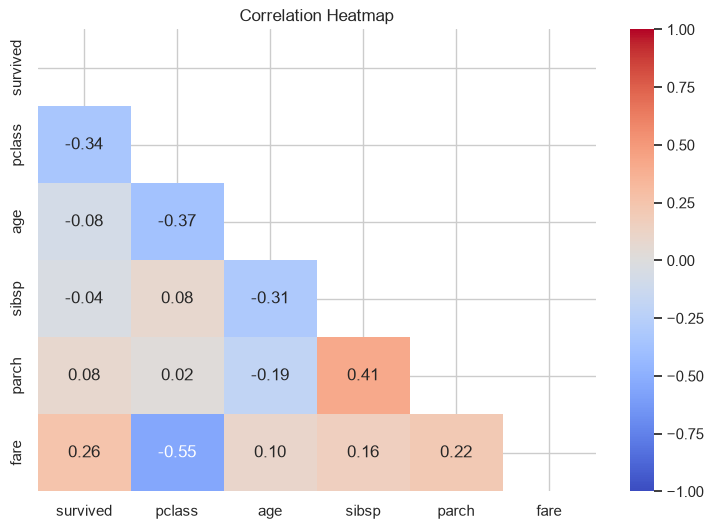

In [28]:
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

히트맵에서 살펴볼 예:

- `pclass`와 `fare`는 어떤 방향의 관계인가?
- `sibsp`와 `parch`는 어느 정도 관계가 있는가?
- `survived`와 비교적 관계가 큰 수치형 변수는 무엇인가?

범주형 변수인 성별이나 승선 도시는 이 상관행렬에 직접 포함되지 않습니다.  
이러한 변수는 앞에서 사용한 그룹별 생존율이나 교차표로 분석하는 것이 적절합니다.

# 11. 분산과 표준편차

분산과 표준편차는 값이 평균을 기준으로 얼마나 퍼져 있는지를 나타냅니다.

- 분산이 작음: 값들이 평균 주변에 모여 있음
- 분산이 큼: 값들이 평균에서 넓게 퍼져 있음
- 표준편차: 분산에 제곱근을 적용한 값으로, 원래 데이터와 같은 단위를 사용

In [29]:
age_variance = df["age"].var()
age_std = df["age"].std()

fare_variance = df["fare"].var()
fare_std = df["fare"].std()

print(f"나이 분산: {age_variance:.2f}")
print(f"나이 표준편차: {age_std:.2f}")
print(f"운임 분산: {fare_variance:.2f}")
print(f"운임 표준편차: {fare_std:.2f}")

나이 분산: 211.02
나이 표준편차: 14.53
운임 분산: 2469.44
운임 표준편차: 49.69


나이와 운임은 단위와 값의 범위가 다르기 때문에 분산의 숫자 크기만으로 두 변수를 단순 비교하면 안 됩니다.  
각 변수 내부에서 값이 얼마나 퍼져 있는지 해석하는 용도로 사용합니다.

# 12. 여러 변수를 한 번에 살펴보기: pairplot

`pairplot()`은 다음 내용을 한 번에 보여줍니다.

- 대각선: 각 변수의 분포
- 나머지 영역: 두 변수 사이의 산점도

전체 컬럼을 모두 사용하면 그래프가 너무 복잡해지므로 주요 수치형 컬럼만 선택합니다.

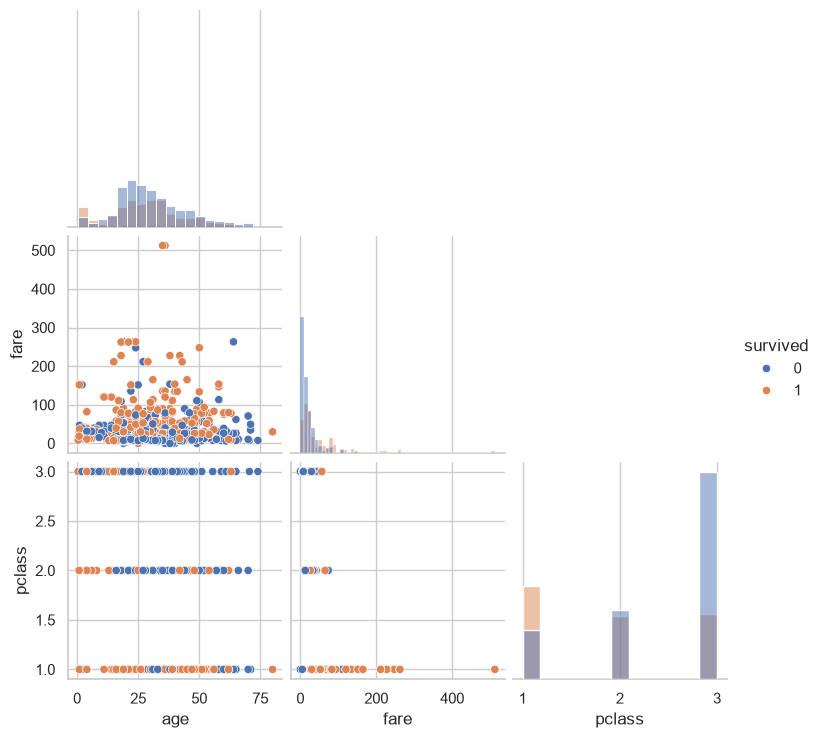

In [30]:
pair_df = df[
    ["survived", "age", "fare", "pclass", "sibsp", "parch"]
].dropna()

sns.pairplot(
    pair_df,
    vars=["age", "fare", "pclass"],
    hue="survived",
    corner=True,
    diag_kind="hist"
)
plt.show()

`pairplot`에서 확인할 내용:

- 생존자와 사망자의 점이 특정 영역에서 구분되는가?
- 객실 등급과 운임 사이에 어떤 관계가 보이는가?
- 나이 분포는 생존 여부에 따라 다르게 나타나는가?

그래프만으로 결론을 확정하기보다는, 앞에서 구한 통계표와 함께 해석해야 합니다.

# 13. 추가 EDA: 혼자 탑승한 승객의 생존율

`alone` 컬럼을 사용해 혼자 탑승한 승객과 가족·동행인이 있는 승객의 생존율을 비교합니다.

In [31]:
alone_survival = (
    df.groupby("alone")["survived"]
      .agg(["count", "mean"])
      .rename(columns={"count": "승객 수", "mean": "생존율"})
)

alone_survival["생존율"] = (alone_survival["생존율"] * 100).round(1)
alone_survival

,승객 수,생존율
alone,,
False,354,50.6
True,537,30.4


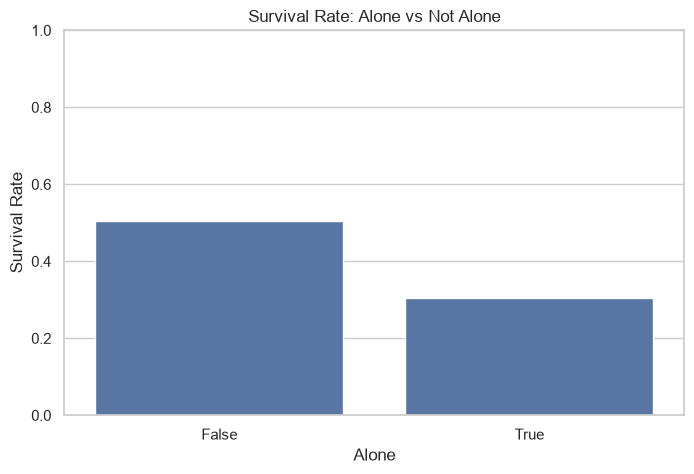

In [32]:
sns.barplot(data=df, x="alone", y="survived", errorbar=None, color="C0")
plt.title("Survival Rate: Alone vs Not Alone")
plt.xlabel("Alone")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

# 14. 추가 EDA: 승선 도시별 생존율

In [33]:
town_summary = (
    df.groupby("embark_town")["survived"]
      .agg(["count", "mean"])
      .rename(columns={"count": "승객 수", "mean": "생존율"})
      .sort_values("생존율", ascending=False)
)

town_summary["생존율"] = (town_summary["생존율"] * 100).round(1)
town_summary

,승객 수,생존율
embark_town,,
Cherbourg,168,55.4
Queenstown,77,39.0
Southampton,644,33.7


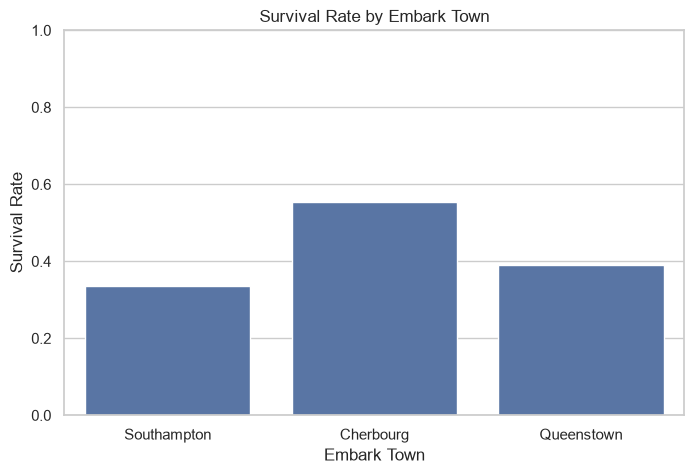

In [34]:
sns.barplot(data=df, x="embark_town", y="survived", errorbar=None, color="C0")
plt.title("Survival Rate by Embark Town")
plt.xlabel("Embark Town")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

승선 도시별 생존율 차이가 도시 자체의 영향이라고 바로 결론 내리면 안 됩니다.

예를 들어 특정 도시에서 1등급 승객의 비율이 높았다면, 실제 생존율 차이는 객실 등급과 연관되어 있을 수 있습니다.  
EDA에서는 이렇게 **다른 변수가 함께 영향을 주는 가능성**을 생각해야 합니다.

# 15. EDA 정리

이번 노트북에서는 Titanic 데이터를 이용해 다음 내용을 확인했습니다.

1. `head()`, `tail()`, `shape`, `columns`, `info()`로 데이터 구조 확인
2. `isna()`로 결측치 개수와 비율 확인
3. `describe()`로 수치형·범주형 데이터 요약
4. `value_counts()`로 범주별 빈도 확인
5. `groupby()`와 `crosstab()`으로 그룹별 생존율 비교
6. 히스토그램으로 나이와 운임 분포 확인
7. 상자 그림으로 이상치 후보 확인
8. 산점도로 두 수치형 변수의 관계 확인
9. 상관계수와 히트맵으로 수치형 변수의 관계 확인
10. `pairplot()`으로 여러 변수의 분포와 관계를 한 번에 확인

EDA의 핵심은 그래프를 그리는 것 자체가 아니라,  
**데이터에 질문을 던지고 결과를 근거로 해석하는 것**입니다.

# 16. 실습 문제

아래 문제를 직접 코드로 해결해 보세요.

1. 어린이(`who == "child"`) 승객 수와 생존율을 구하세요.
2. 1등급 여성 승객의 생존율을 구하세요.
3. 객실 등급별 평균 나이와 평균 운임을 표로 출력하세요.
4. 승선 도시와 객실 등급을 함께 고려한 생존율 표를 만드세요.
5. `age`의 결측치가 전체의 몇 퍼센트인지 계산하세요.
6. 나이를 0~9세, 10~19세처럼 구간으로 나누어 생존율을 비교해 보세요.
7. 가족 수를 `sibsp + parch`로 계산한 뒤 가족 수와 생존율의 관계를 분석해 보세요.

In [35]:
# 실습 코드를 작성하세요.